In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_scor
import kagglehub

In [19]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ziya07/smart-manufacturing-maintenance-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'smart-manufacturing-maintenance-dataset' dataset.
Path to dataset files: /kaggle/input/smart-manufacturing-maintenance-dataset


In [21]:
df = pd.read_csv(os.path.join(path, "smart_maintenance_dataset.csv"))
df.head()

,Machine_ID,Temp_C,Vibration_mm_s,Pressure_Bar,Acoustic_dB,Inspection_Duration_min,Downtime_Cost_USD,Technician_Availability_pct,Failure_Prob,Maintenance_Priority
0,M004,70.415631,3.036378,5.582562,74.494678,68,3112,99,0.48,2
1,M006,74.509666,2.787866,4.916866,64.017351,127,522,63,0.50,2
2,M009,78.724957,2.067099,4.597601,68.772382,68,836,84,0.47,2
3,M006,76.677258,1.998635,5.012083,76.909872,142,3799,80,0.48,2
4,M009,53.381545,3.844676,5.176345,84.855886,88,2710,78,0.51,2


# **Data clining**

In [22]:
df.describe()

,Temp_C,Vibration_mm_s,Pressure_Bar,Acoustic_dB,Inspection_Duration_min,Downtime_Cost_USD,Technician_Availability_pct,Failure_Prob,Maintenance_Priority
count,1430.000000,1430.000000,1430.000000,1430.000000,1430.000000,1430.000000,1430.000000,1430.000000,1430.000000
mean,75.457760,2.492967,5.006490,70.167973,89.217483,2718.568531,74.430070,0.491965,1.836364
std,9.957299,0.993764,0.493718,10.134302,34.830122,1296.430507,14.450429,0.056898,0.490433
min,41.483895,-0.886814,3.477036,35.330958,30.000000,502.000000,50.000000,0.310000,1.000000
25%,68.811195,1.790770,4.680468,63.290407,57.250000,1595.000000,62.000000,0.450000,2.000000
50%,75.473914,2.493069,5.000584,70.219443,89.000000,2681.500000,74.000000,0.490000,2.000000
75%,82.319170,3.201869,5.340422,77.099673,120.000000,3861.750000,87.000000,0.530000,2.000000
max,109.958778,5.420753,7.026275,97.989795,149.000000,4998.000000,99.000000,0.660000,3.000000


In [23]:
df.shape

(1430, 10)

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.isnull().sum()

,0
Machine_ID,0
Temp_C,0
Vibration_mm_s,0
Pressure_Bar,0
Acoustic_dB,0
Inspection_Duration_min,0
Downtime_Cost_USD,0
Technician_Availability_pct,0
Failure_Prob,0
Maintenance_Priority,0


In [19]:
df['Maintenance_Priority'].value_counts()

,count
Maintenance_Priority,
2,1048
1,308
3,74


In [24]:
df.dtypes

,0
Machine_ID,object
Temp_C,float64
Vibration_mm_s,float64
Pressure_Bar,float64
Acoustic_dB,float64
Inspection_Duration_min,int64
Downtime_Cost_USD,int64
Technician_Availability_pct,int64
Failure_Prob,float64
Maintenance_Priority,int64


# **Distribution**

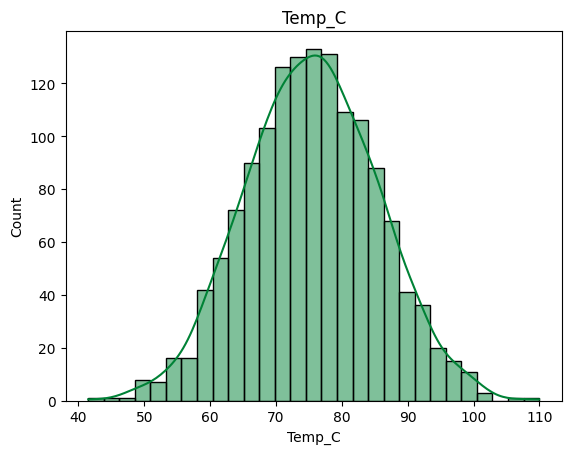

In [35]:
sns.histplot(df['Temp_C'], kde=True, color='#008236')
plt.title('Temp_C')
plt.show()

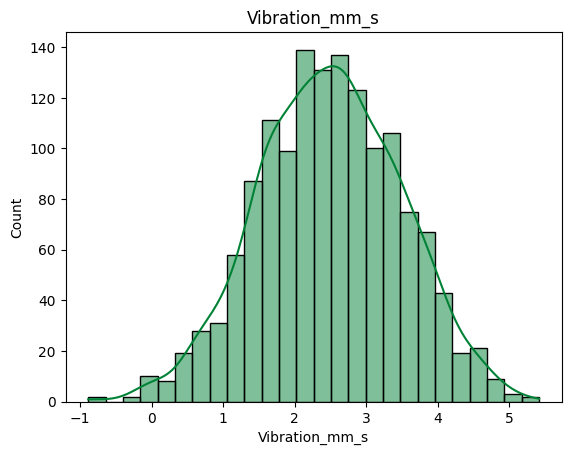

In [32]:
sns.histplot(df['Vibration_mm_s'], kde=True, color='#008236')
plt.title('Vibration_mm_s')
plt.show()

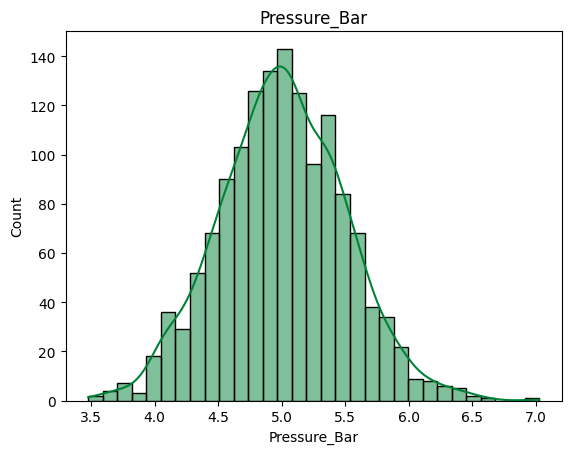

In [33]:
sns.histplot(df['Pressure_Bar'], kde=True, color='#008236')
plt.title('Pressure_Bar')
plt.show()

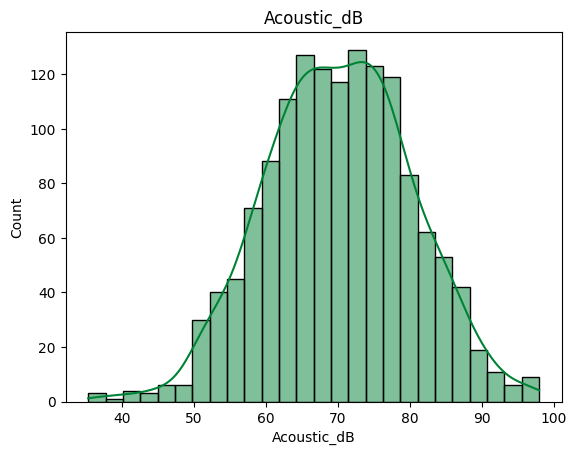

In [34]:
sns.histplot(df['Acoustic_dB'], kde=True, color='#008236')
plt.title('Acoustic_dB')
plt.show()

# **Outlier**

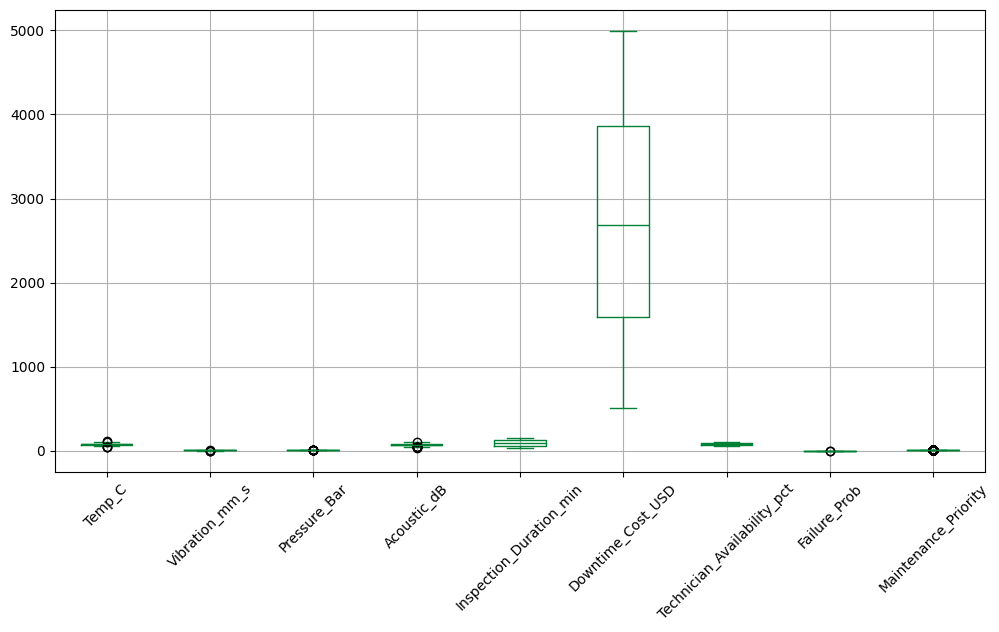

In [47]:
plt.figure(figsize=(12, 6))
df.boxplot(color='#008236')
plt.xticks(rotation=45)
plt.show()

# **Correlation**

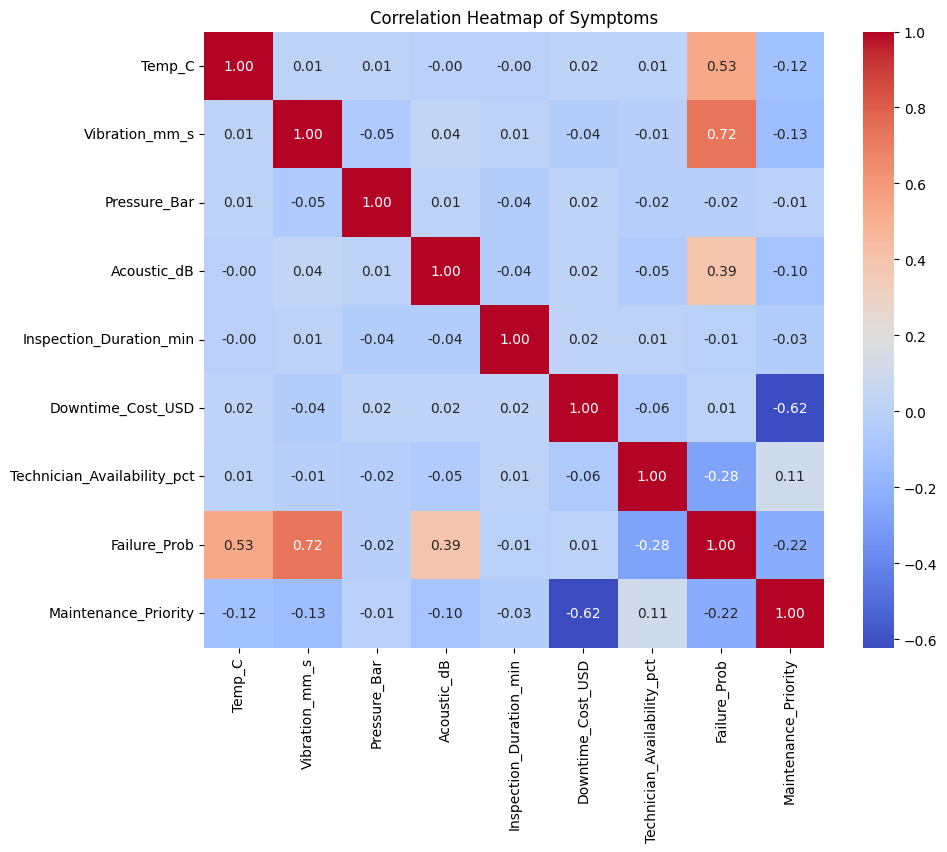

In [49]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Symptoms')
plt.show()

# **Feature Engineering**

In [69]:
df.columns.tolist()

['Machine_ID',
 'Temp_C',
 'Vibration_mm_s',
 'Pressure_Bar',
 'Acoustic_dB',
 'Inspection_Duration_min',
 'Downtime_Cost_USD',
 'Technician_Availability_pct',
 'Failure_Prob',
 'Maintenance_Priority',
 'Vibration_High_Risk',
 'Risk_Score',
 'Vibration_Deviation',
 'Recommended_Action',
 'Estimated_Downtime']

In [58]:
#Warning flag if vibration exceeds the danger.
df['Vibration_High_Risk'] = (df['Vibration_mm_s'] > 4.0)
df.head()

,Machine_ID,Temp_C,Vibration_mm_s,Pressure_Bar,Acoustic_dB,Inspection_Duration_min,Downtime_Cost_USD,Technician_Availability_pct,Failure_Prob,Maintenance_Priority,Vibration_High_Risk,Risk_Score,Vibration_Deviation
0,M004,70.415631,3.036378,5.582562,74.494678,68,3112,99,0.48,2,False,0.558042,0.631944
1,M006,74.509666,2.787866,4.916866,64.017351,127,522,63,0.50,2,False,0.452681,0.335619
2,M009,78.724957,2.067099,4.597601,68.772382,68,836,84,0.47,2,False,0.472261,-0.496271
3,M006,76.677258,1.998635,5.012083,76.909872,142,3799,80,0.48,2,False,0.535664,-0.453612
4,M009,53.381545,3.844676,5.176345,84.855886,88,2710,78,0.51,2,False,0.616084,1.281306


In [63]:
#Risk_Score a composite risk indicator based on three sensors.
df['Risk_Score'] = (df['Temp_C'] + df['Vibration_mm_s']*10 + df['Acoustic_dB']) / 3
df.head()

,Machine_ID,Temp_C,Vibration_mm_s,Pressure_Bar,Acoustic_dB,Inspection_Duration_min,Downtime_Cost_USD,Technician_Availability_pct,Failure_Prob,Maintenance_Priority,Vibration_High_Risk,Risk_Score,Vibration_Deviation
0,M004,70.415631,3.036378,5.582562,74.494678,68,3112,99,0.48,2,0,58.424696,0.631944
1,M006,74.509666,2.787866,4.916866,64.017351,127,522,63,0.50,2,0,55.468559,0.335619
2,M009,78.724957,2.067099,4.597601,68.772382,68,836,84,0.47,2,0,56.056110,-0.496271
3,M006,76.677258,1.998635,5.012083,76.909872,142,3799,80,0.48,2,0,57.857825,-0.453612
4,M009,53.381545,3.844676,5.176345,84.855886,88,2710,78,0.51,2,0,58.894731,1.281306


# **Modeling**

In [ ]:
# Without 'Failure_Prob'in features because it's directly linked to
# Maintenance_Priority,including it caused data leakage
features = ['Temp_C', 'Vibration_mm_s', 'Pressure_Bar', 'Acoustic_dB',
            'Inspection_Duration_min', 'Downtime_Cost_USD',
            'Technician_Availability_pct',
            'Vibration_Deviation', 'Vibration_High_Risk']

X = df[features]
y = df['Maintenance_Priority']#target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)#handeling imbalanced data by adding more weight stratify=y
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        62
           2       0.99      1.00      1.00       209
           3       1.00      0.87      0.93        15

    accuracy                           0.99       286
   macro avg       1.00      0.96      0.97       286
weighted avg       0.99      0.99      0.99       286

